In [1]:
import torchcurves.functional as tcf
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional
import torch
from torch import nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader

# Simulate auctions

In [2]:
@dataclass
class Player:
    mean_budget: float
    budget: float
    preferences: np.typing.NDArray

    @classmethod
    def draw_player(cls, rng=None, mean_budget=1000, dim=10):
        if rng is None:
            rng = np.random

        return cls(
            mean_budget=mean_budget,
            budget=rng.exponential(scale=mean_budget),
            preferences=rng.normal(size=dim)
        )

    def reset_budget(self, rng=None):
        if rng is None:
            rng = np.random

        self.budget = rng.exponential(scale=self.mean_budget)

    def bid(self, auction_features: np.typing.NDArray, rng=None):
        if rng is None:
            rng = np.random

        # linear preferences
        mean_bid = np.reciprocal(np.linalg.norm(self.preferences - auction_features))
        return min(self.budget, rng.exponential(scale=mean_bid))

    def charge(self, amount: float):
        self.budget -= amount

In [3]:
n_players = 20     # us and n_players - 1 competitors
feature_dim = 3
n_auctions = 10000
n_days = 10
mean_budget = 2 * n_auctions * np.sqrt(feature_dim) / n_players
rng = np.random.default_rng(42)

In [4]:
players = [Player.draw_player(rng, dim=feature_dim, mean_budget=mean_budget) for _ in range(n_players)]
auction_features = []
budget_fractions = []
our_bids = []
our_wins = []
for day in range(n_days):
    for i in range(n_auctions):
        current_auction_features = rng.normal(size=feature_dim)

        bids = np.asarray([player.bid(current_auction_features, rng) for player in players])
        winner = np.argmax(bids)
        winner_bid = bids[winner]

        auction_features.append(current_auction_features)
        budget_fractions.append(players[0].budget / players[0].mean_budget)
        our_bids.append(bids[0])
        our_wins.append(1. if winner == 0 and bids[0] > 0 else 0.)

        players[winner].charge(winner_bid)

    for player in players:
        player.reset_budget(rng)

auction_features = np.vstack(auction_features)
budget_fractions = np.asarray(budget_fractions)
X = np.hstack((auction_features, budget_fractions.reshape(-1, 1)))
our_bids = np.asarray(our_bids)
our_wins = np.asarray(our_wins)

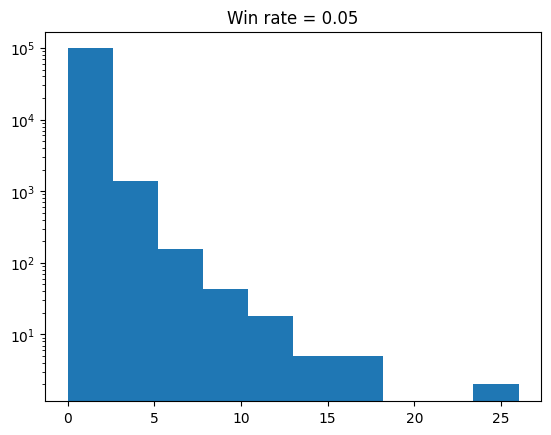

In [5]:
plt.hist(our_bids, log=True)
plt.title(f'Win rate = {our_wins.mean():.2f}')
plt.show()

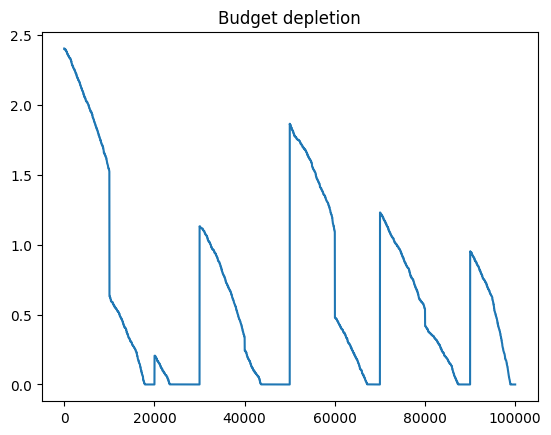

In [6]:
plt.plot(budget_fractions)
plt.title('Budget depletion')
plt.show()

Text(0.5, 1.0, 'Budget depletion vs. bid')

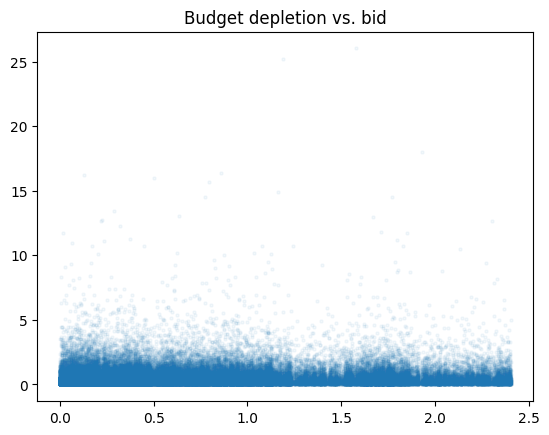

In [7]:
plt.scatter(budget_fractions, our_bids, s=5, alpha=0.05)
plt.plot()
plt.title('Budget depletion vs. bid')

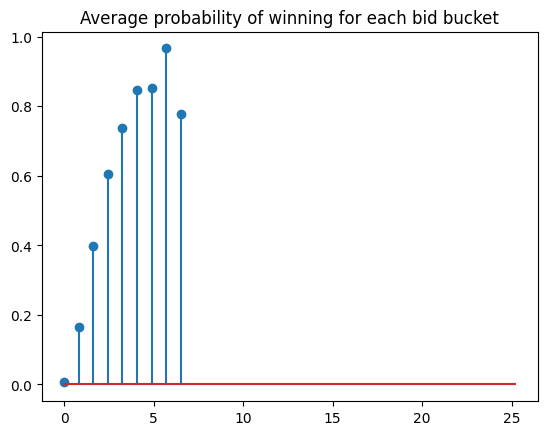

In [8]:
def bucket_means(b, p, n):
    # Uniform bucket edges on [min(b), max(b)]
    edges = np.linspace(b.min(), b.max(), n + 1)

    # Map each b to a bucket index in [0, n-1]
    idx = np.searchsorted(edges, b, side='right') - 1
    idx = np.clip(idx, 0, n - 1)

    # Weighted sum and counts per bucket
    sums = np.bincount(idx, weights=p, minlength=n)
    counts = np.bincount(idx, minlength=n)

    # Means, with zeros for empty buckets
    means = np.divide(sums, counts,
                      out=np.full(n, np.nan, dtype=float),
                      where=counts > 30)

    return edges[:-1], means

plt.stem(*bucket_means(our_bids, our_wins, 32))
plt.title('Average probability of winning for each bid bucket')
plt.show()

# Prepare train / validation data

In [9]:
def to_torch(mask, *arrays):
    tensors = (torch.as_tensor(t[mask], dtype=torch.get_default_dtype()) for t in arrays)
    return TensorDataset(*tensors)

In [10]:
train_frac = 0.8
train_mask = rng.random(size=X.shape[0]) < train_frac
train_ds = to_torch(train_mask, X, our_bids, our_wins)
val_ds = to_torch(~train_mask, X, our_bids, our_wins)
max_bid = np.max(our_bids).item()

# Define the model

In [11]:
def make_mlp(input_dim: int, output_dim: int, num_hidden_layers: int, hidden_dim: int):
        return nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            *(
                layer for _ in range(num_hidden_layers) for layer in [nn.Linear(hidden_dim, hidden_dim), nn.ReLU()]
            ),
            nn.Linear(hidden_dim, output_dim),
        )

In [12]:
class BidModel(nn.Module):
    def __init__(self, input_dim: int, num_coefficients: int, num_hidden_layers: int):
        super().__init__()
        self.degree = 3
        hidden_dim = 4 * max(input_dim, num_coefficients)
        self.mlp = make_mlp(input_dim, num_coefficients, num_hidden_layers, hidden_dim)
        self.register_buffer("knots", tcf.uniform_augmented_knots(num_coefficients, degree=self.degree, k_min=0, k_max=1))

    def forward(self, auction_features: torch.Tensor, bid: torch.Tensor) -> torch.Tensor:
        # map auction features to increasing spline coefficients via MLP + increasing transform
        coefficients = self.mlp(auction_features)
        increasing_coefficients = self._make_increasing(coefficients)

        # map bids to [0, 1] using the arctan (or any other) normalization
        mapped_bid = tcf.arctan(bid)

        # compute a B-Spline function that by-design increases with the bid!
        return tcf.bspline_curves(
            mapped_bid.unsqueeze(-1),
            increasing_coefficients.unsqueeze(-1),
            self.knots,
            self.degree
        ).squeeze([-1, -2])

    @staticmethod
    def _make_increasing(x):
        initial = x[..., :1]
        increments = nn.functional.softplus(x[..., 1:])
        concatenated = torch.concat((initial, increments), dim=-1)
        return torch.cumsum(concatenated, dim=-1)

In [13]:
# model params
num_coefficients = 50
num_hidden_layers = 10

# training params
num_epochs = 10
batch_size = 128
lr = 5e-4
weight_decay = 1e-4

# create model, loss, optimizer, and dataloaders
model = BidModel(X.shape[1], num_coefficients, num_hidden_layers)
loss = torch.nn.BCEWithLogitsLoss()
optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=len(val_ds), shuffle=False)

# training loop
for epoch in range(1, 1 + num_epochs):
    epoch_loss = torch.tensor(0.)
    for X_batch, bid_batch, win_batch in train_dl:
        optim.zero_grad()
        y_pred = model(X_batch, bid_batch)
        loss_val = loss(y_pred, win_batch)
        loss_val.backward()
        optim.step()

        with torch.no_grad():
            epoch_loss += loss_val * len(X_batch)
    epoch_loss /= len(train_ds)

    with torch.no_grad():
        for X_batch, bid_batch, win_batch in val_dl:
            y_pred = model(X_batch, bid_batch)
            valid_loss = loss(y_pred, win_batch)

    print(f'Epoch = {epoch}, Loss = {epoch_loss:.4f}, Valid Loss = {valid_loss:.4f}')

/home/alex/git/torchcurves/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:824: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch = 1, Loss = 0.3598, Valid Loss = 0.1185
Epoch = 2, Loss = 0.1210, Valid Loss = 0.1165
Epoch = 3, Loss = 0.1195, Valid Loss = 0.1123
Epoch = 4, Loss = 0.1174, Valid Loss = 0.1139
Epoch = 5, Loss = 0.1159, Valid Loss = 0.1116
Epoch = 6, Loss = 0.1152, Valid Loss = 0.1109
Epoch = 7, Loss = 0.1160, Valid Loss = 0.1117
Epoch = 8, Loss = 0.1150, Valid Loss = 0.1109
Epoch = 9, Loss = 0.1151, Valid Loss = 0.1103
Epoch = 10, Loss = 0.1149, Valid Loss = 0.1112


# Take several random auction features and see P(win | auction, bid) as a function of the bid

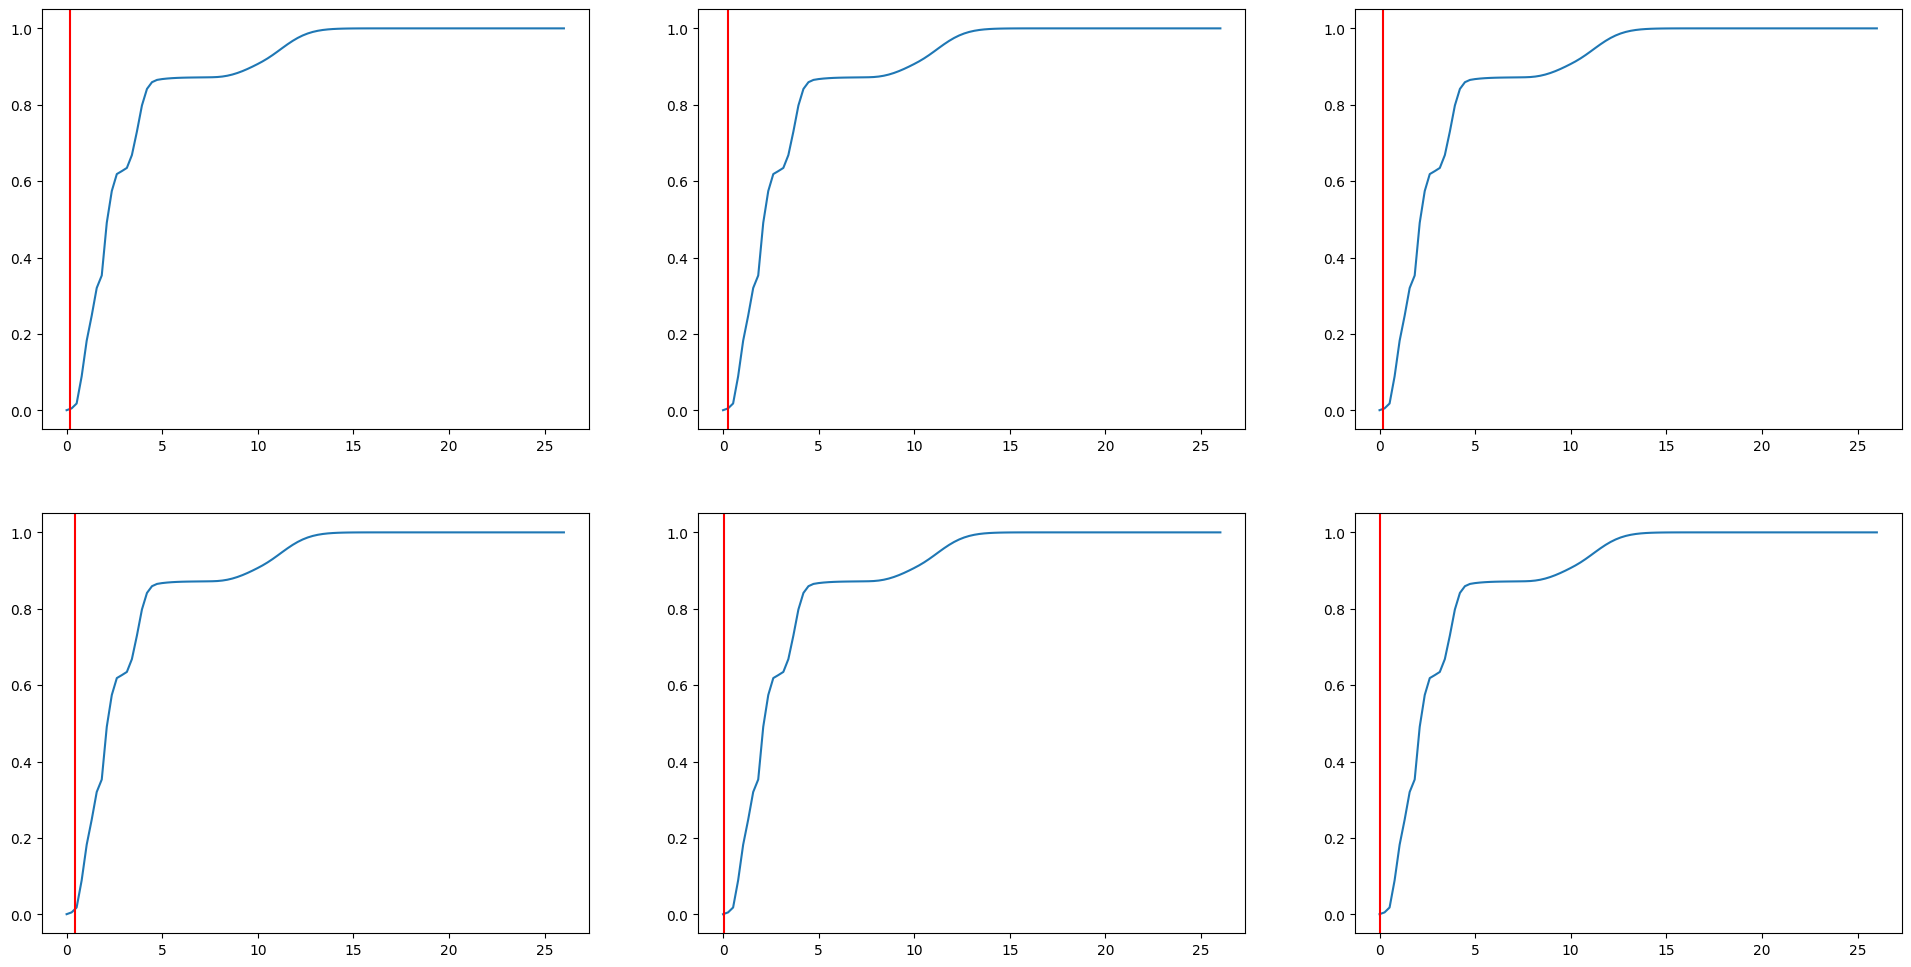

In [14]:
num_plot_rows = 2
num_plot_cols = 3
plot_resolution = 100

fig, axs = plt.subplots(num_plot_rows, num_plot_cols, figsize=(8 * num_plot_cols, 6 * num_plot_rows))
plot_bids = torch.linspace(0, max_bid, plot_resolution)
for ax, (auction_features, bid, win_label) in zip(axs.ravel(), DataLoader(val_ds, shuffle=True)):
    with torch.no_grad():
        pred_logits = model(auction_features.expand(plot_resolution, -1), plot_bids)
        pred_probs = torch.sigmoid(pred_logits)

    ax.plot(plot_bids, pred_probs)
    ax.axvline(bid, color=('blue' if win_label == 1 else 'red'))